# DTL: classify probability map

In [1]:
!python -m pip install .. --quiet

import ee 

ee.Authenticate() 
ee.Initialize(project='epistem2')

# Load probability stack from asset

prob_stack = ee.Image('projects/epistem2/assets/probability_stack_Aceh_2020_v5')

provinces = ee.FeatureCollection('projects/epistem2/assets/AOI_Sumatra_Provinces')
province_list = provinces.toList(provinces.size())
aoi = ee.Feature(province_list.get(0)).geometry()

stacked_landsat = ee.Image('projects/epistem2/assets/stacked_landsat_2020_Sumatera')
band_names = stacked_landsat.bandNames()

In [2]:
# Derive class_ids directly from prob_stack's band names — guaranteed to match
prob_band_names = prob_stack.bandNames().getInfo()  # e.g. ['prob_18', 'prob_2', ...]

# Extract the numeric class id from each band name, keep prob_stack's own order
class_ids_list = [int(b.split('_')[1]) for b in prob_band_names]
class_ids = ee.List(class_ids_list)

print("class_ids (from prob_stack):", class_ids_list)

# prob_stack is already in this exact order — no need to reorder/select
max_prob_index = prob_stack.toArray().arrayArgmax().arrayGet(0)

final_lc = max_prob_index.remap(
    ee.List.sequence(0, class_ids.size().subtract(1)),
    class_ids
).rename('classification')

max_confidence = prob_stack.toArray().arrayReduce(ee.Reducer.max(), [0]).arrayGet([0]).rename('confidence')

class_ids (from prob_stack): [18, 2, 4, 23, 20, 1, 17, 24, 9, 13, 7, 8, 21]


In [ ]:
import geemap

Map = geemap.Map()
Map.centerObject(aoi, 9)

class_ids_list = class_ids.getInfo()
class_palette = ['e31a1c','33a02c','1f78b4','ff7f00','b15928',
                  '6a3d9a','a6cee3','b2df8a','fb9a99','fdbf6f','cab2d6']

n_classes = class_ids.size().getInfo()

classification_vis = {
    'min': min(class_ids_list),
    'max': max(class_ids_list),
    'palette': class_palette[:len(class_ids_list)]
}


confidence_vis = {
    'min': 0,
    'max': 100,
    'palette': ['ffffcc', 'ffeda0', 'fed976', 'feb24c', 'fd8d3c', 'fc4e2a', 'e31a1c', 'b10026']
}

Map.addLayer(aoi, {}, 'AOI', True)
Map.addLayer(final_lc.clip(aoi), classification_vis, 'Final Classification')
Map.addLayer(max_confidence.clip(aoi), confidence_vis, 'Confidence', False)

# Map.add_legend(
#     title="Land Cover Class",
#     labels=[str(c) for c in class_ids.getInfo()],
#     colors=class_palette[:n_classes]
# )

Map

In [4]:
# %%
# Compute area per class using pixelArea + group reducer
area_image = ee.Image.pixelArea().addBands(final_lc)

area_stats = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(
        groupField=1,
        groupName='class'
    ),
    geometry=aoi,
    scale=100,
    maxPixels=1e13,
    bestEffort=True
)

area_stats_info = area_stats.getInfo()
print(area_stats_info)

# %%
import pandas as pd

# Parse into a clean DataFrame
groups = area_stats_info['groups']

df_stats = pd.DataFrame(groups)
df_stats = df_stats.rename(columns={'class': 'class_id', 'sum': 'area_m2'})
df_stats['area_ha'] = df_stats['area_m2'] / 10_000
df_stats['area_km2'] = df_stats['area_m2'] / 1_000_000
df_stats['pct_of_total'] = (df_stats['area_m2'] / df_stats['area_m2'].sum()) * 100

df_stats = df_stats.sort_values('area_ha', ascending=False).reset_index(drop=True)
df_stats

# %%
# Pixel counts per class (useful sanity check alongside area)
pixel_count_stats = final_lc.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi,
    scale=100,
    maxPixels=1e13,
    bestEffort=True
).getInfo()

pixel_counts = pixel_count_stats['classification']
df_pixels = pd.DataFrame(
    [{'class_id': int(k), 'pixel_count': v} for k, v in pixel_counts.items()]
).sort_values('pixel_count', ascending=False).reset_index(drop=True)

df_pixels

# %%
# Merge for a single summary table
df_summary = df_stats.merge(df_pixels, on='class_id')
df_summary = df_summary[['class_id', 'pixel_count', 'area_ha', 'area_km2', 'pct_of_total']]
df_summary

{'groups': [{'class': 1, 'sum': 22332379568.559242}, {'class': 2, 'sum': 8900458216.00529}, {'class': 13, 'sum': 195841108.71577433}, {'class': 17, 'sum': 39629.326171875}, {'class': 18, 'sum': 15357274357.454796}, {'class': 20, 'sum': 819262780.660872}, {'class': 23, 'sum': 583402103.2188456}]}


,class_id,pixel_count,area_ha,area_km2,pct_of_total
0,1,2.254487e+06,2.233238e+06,22332.379569,46.343643
1,18,1.550889e+06,1.535727e+06,15357.274357,31.869064
2,2,8.986666e+05,8.900458e+05,8900.458216,18.470027
3,20,8.274871e+04,8.192628e+04,819.262781,1.700115
4,23,5.893507e+04,5.834021e+04,583.402103,1.210663
5,13,1.978008e+04,1.958411e+04,195.841109,0.406405
6,17,4.000000e+00,3.962933e+00,0.039629,0.000082


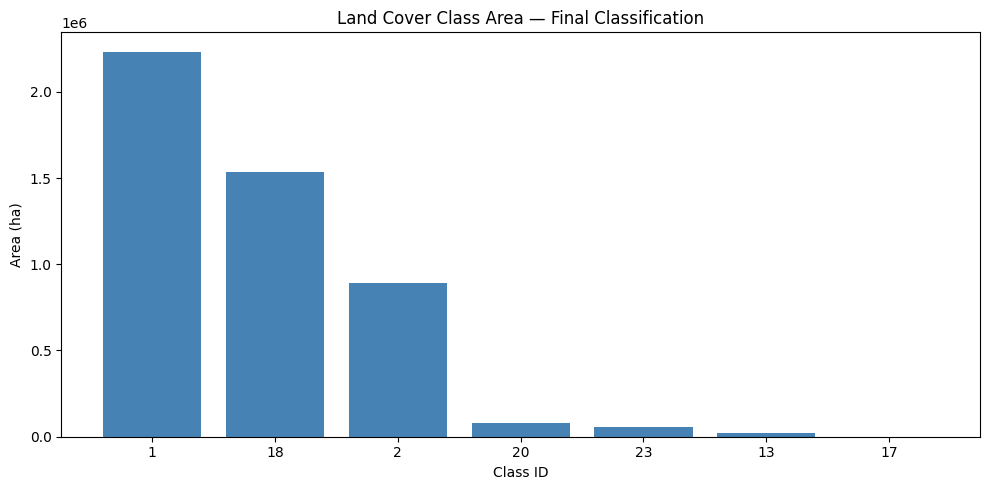

In [5]:
# quick bar chart of area by class
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_summary['class_id'].astype(str), df_summary['area_ha'], color='steelblue')
ax.set_xlabel('Class ID')
ax.set_ylabel('Area (ha)')
ax.set_title('Land Cover Class Area — Final Classification')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# confidence stats per class (mean confidence for pixels assigned to each class)
confidence_by_class = max_confidence.addBands(final_lc).reduceRegion(
    reducer=ee.Reducer.mean().group(
        groupField=1,
        groupName='class'
    ),
    geometry=aoi,
    scale=100,
    maxPixels=1e13,
    bestEffort=True
).getInfo()

df_conf = pd.DataFrame(confidence_by_class['groups']).rename(
    columns={'class': 'class_id', 'mean': 'mean_confidence'}
)

df_summary_full = df_summary.merge(df_conf, on='class_id')
df_summary_full

,class_id,pixel_count,area_ha,area_km2,pct_of_total,mean_confidence
0,1,2.254487e+06,2.233238e+06,22332.379569,46.343643,69.527966
1,18,1.550889e+06,1.535727e+06,15357.274357,31.869064,51.770868
2,2,8.986666e+05,8.900458e+05,8900.458216,18.470027,49.549834
3,20,8.274871e+04,8.192628e+04,819.262781,1.700115,60.660915
4,23,5.893507e+04,5.834021e+04,583.402103,1.210663,37.037295
5,13,1.978008e+04,1.958411e+04,195.841109,0.406405,29.961182
6,17,4.000000e+00,3.962933e+00,0.039629,0.000082,24.750000


In [8]:
# Export to Earth Engine Asset
task = ee.batch.Export.image.toDrive(
    image=final_lc,
    description='final_lc_Aceh_2020_v5',
    folder='GEE_exports',
    region=aoi,
    scale=100,
    maxPixels=1e13
)

task.start()